In [143]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re
from scipy import stats
import utils_multi as utils
import seaborn as sns
import pingouin as pg
import matplotlib.cm as cm

import statsmodels.stats.power as smp
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM
from tqdm import tqdm


from natsort import index_natsorted

# plt.rcParams['font.family'] = 'Times New Roman'
# plt.rcParams['font.family'] = 'Calibri'

path_figs = "./Figs/"

fingers = ['1', '2', '3', '4', '5']

iti = 1000 # msecs for inter-trial interval
planTime = 2000 # msecs for precue time
feedbackTime = 2000 # msecs for feedback time


total_sub_num = 20
num_sessions = 1
num_blocks_per_session = 31
num_trials_per_block = 30

# sub_nums = [1,2]
sub_nums = [1]

utils.set_figure_style("1col")
sns.color_palette('colorblind')


[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [144]:
subjs = pd.read_csv(utils.path_misc+'subjs.csv', sep = '\t')

subjs = subjs[subjs['subNum'].isin(sub_nums)].reset_index(drop=True)


In [145]:
subjs.columns

Index(['subNum', 'BN', 'TN', 'TotalTrialNum', 'targetForce1', 'targetForce2',
       'targetForce3', 'targetForce4', 'targetForce5', 'endForce1',
       'endForce2', 'endForce3', 'endForce4', 'endForce5',
       'endForcePurturbed1', 'endForcePurturbed2', 'endForcePurturbed3',
       'endForcePurturbed4', 'endForcePurturbed5', 'purturbation1',
       'purturbation2', 'purturbation3', 'purturbation4', 'purturbation5',
       'forceGain', 'trialCorr', 'trialErrorType', 'num_targets'],
      dtype='str')

In [146]:
subjs_correct = utils.remove_error_trials(subjs).copy()

In [147]:
subjs_correct.columns

Index(['subNum', 'BN', 'TN', 'TotalTrialNum', 'targetForce1', 'targetForce2',
       'targetForce3', 'targetForce4', 'targetForce5', 'endForce1',
       'endForce2', 'endForce3', 'endForce4', 'endForce5',
       'endForcePurturbed1', 'endForcePurturbed2', 'endForcePurturbed3',
       'endForcePurturbed4', 'endForcePurturbed5', 'purturbation1',
       'purturbation2', 'purturbation3', 'purturbation4', 'purturbation5',
       'forceGain', 'trialCorr', 'trialErrorType', 'num_targets'],
      dtype='str')

In [148]:
def extract_chord_form_target_force(row):
    chord = ''
    for i in range(1, 6):
        if row[f'targetForce{i}'] != 0:
            chord += str(i)
    return chord

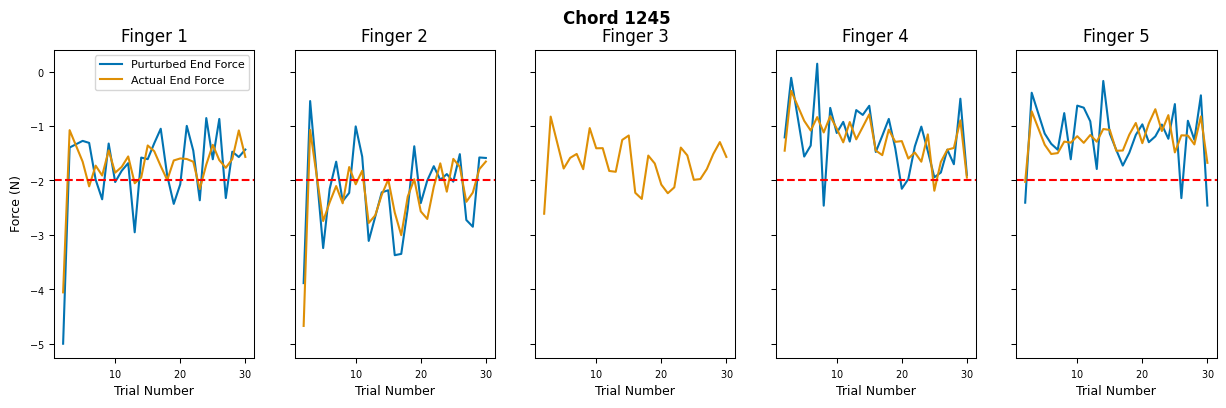

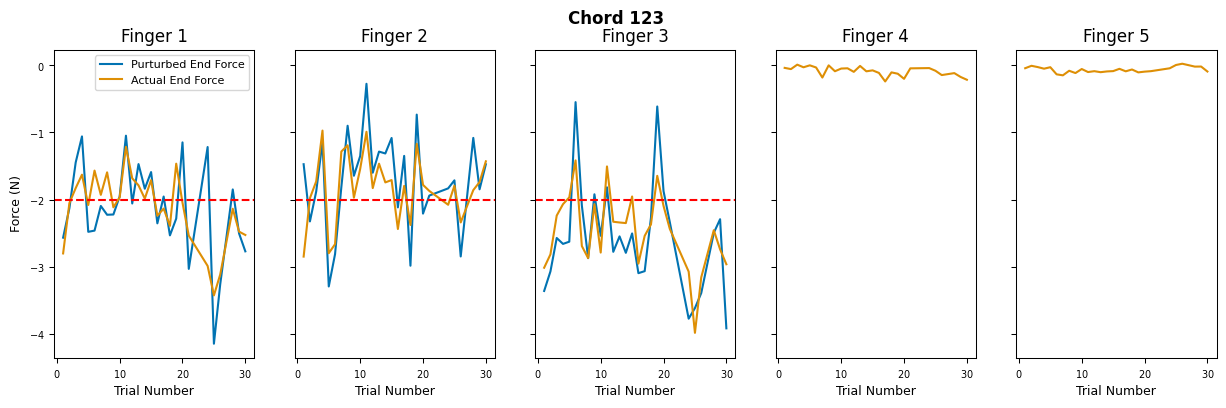

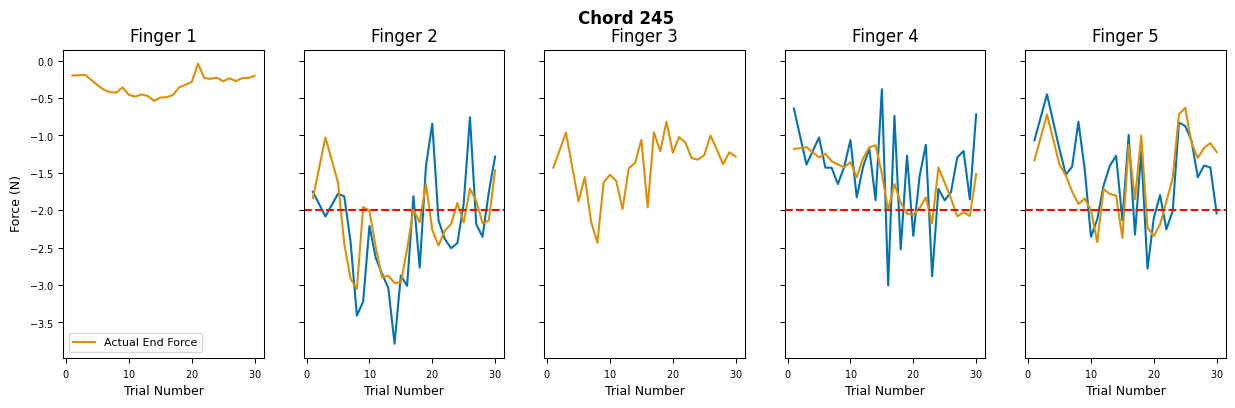

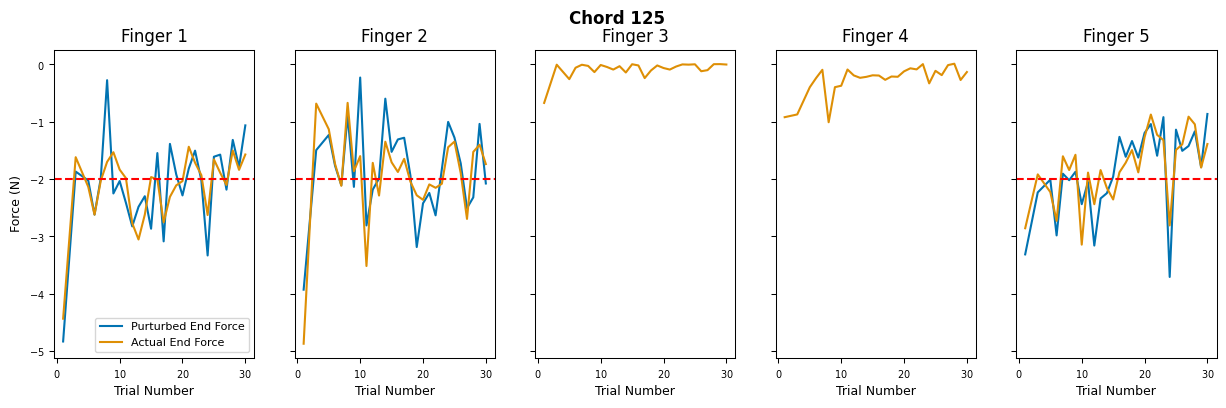

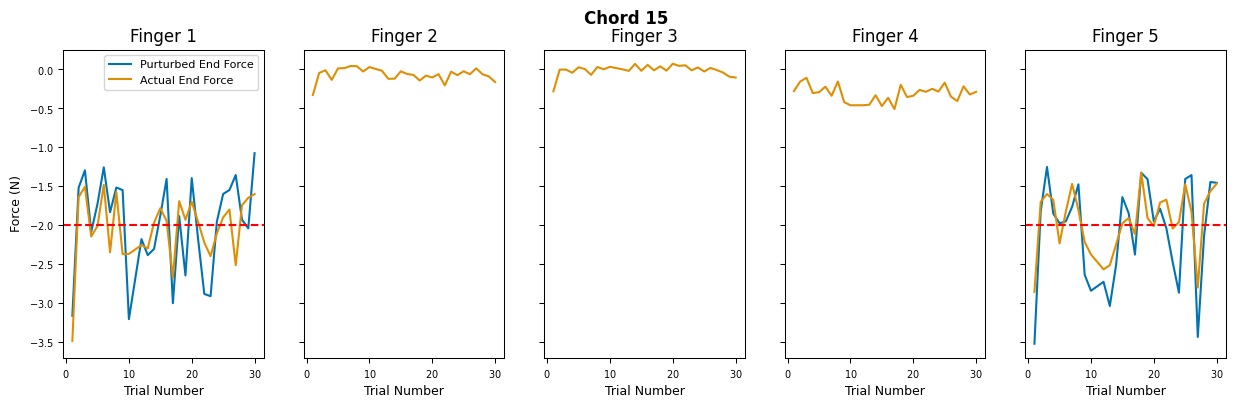

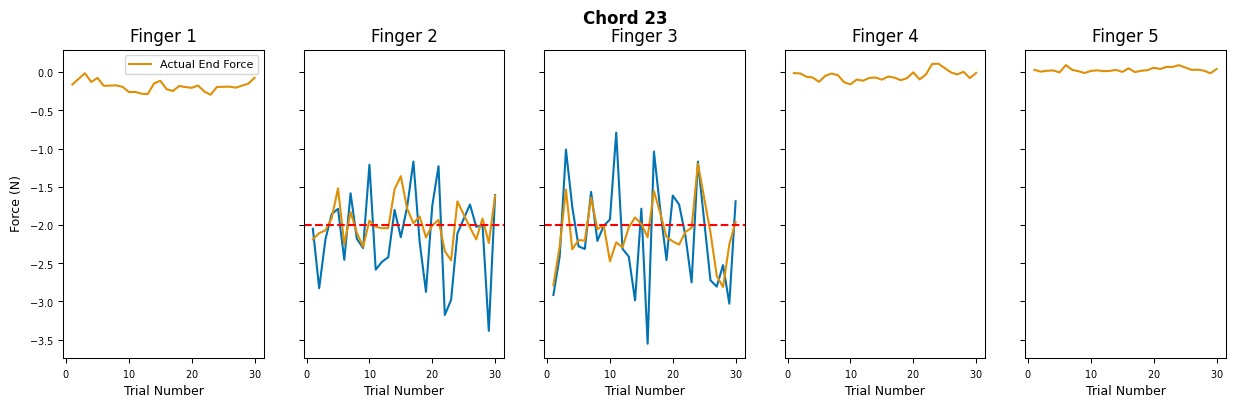

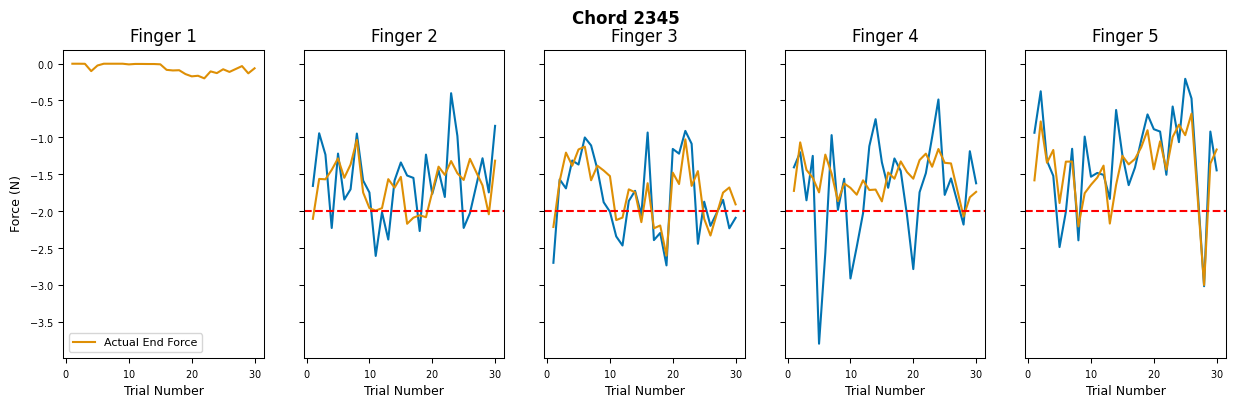

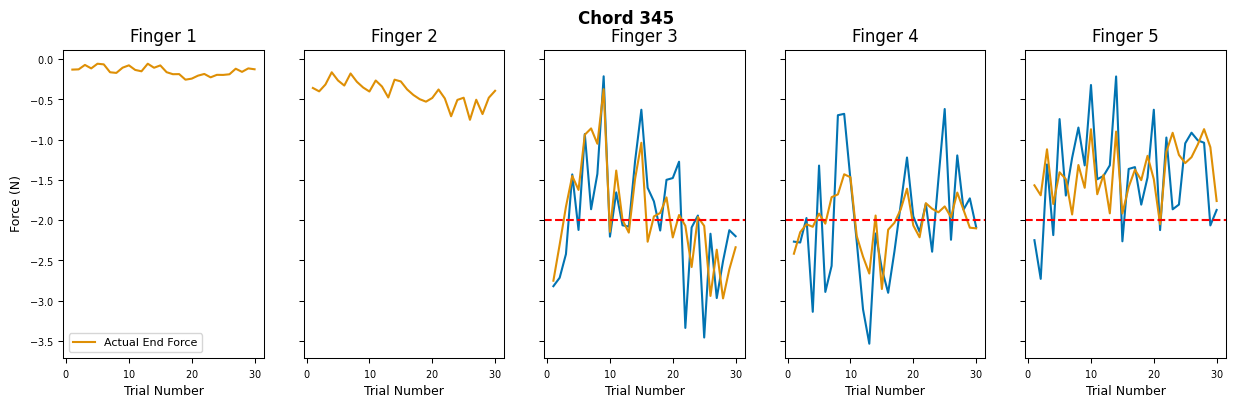

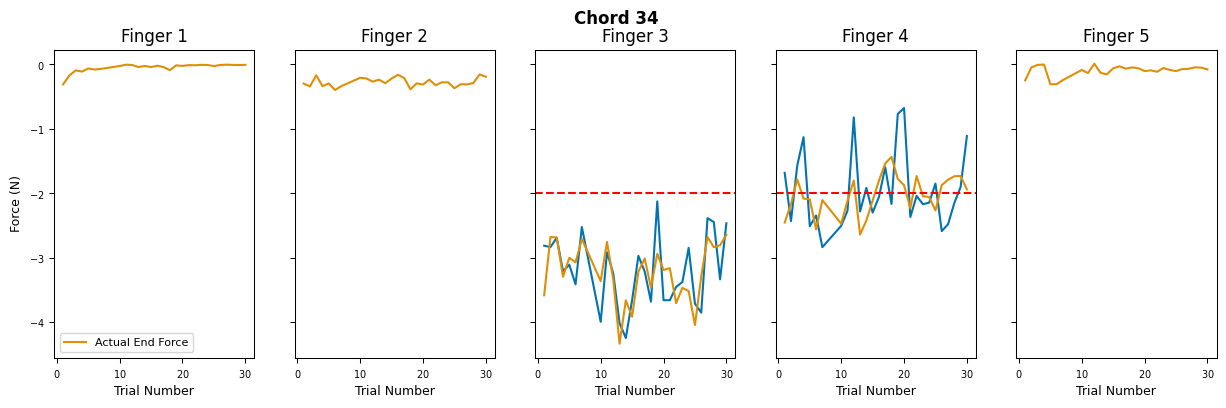

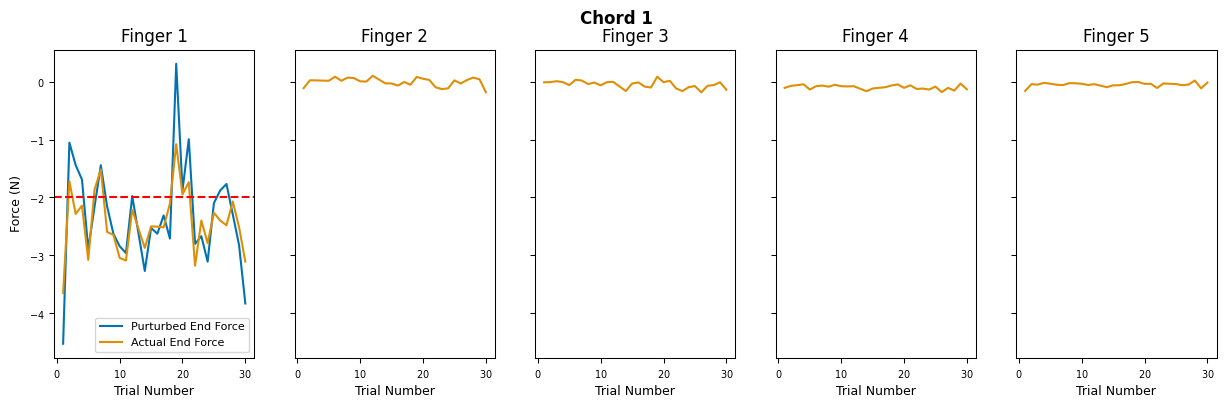

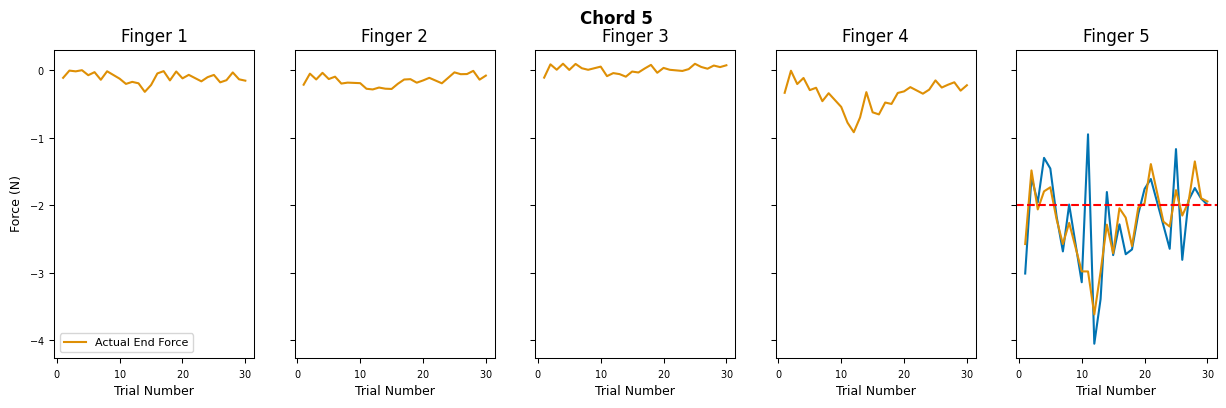

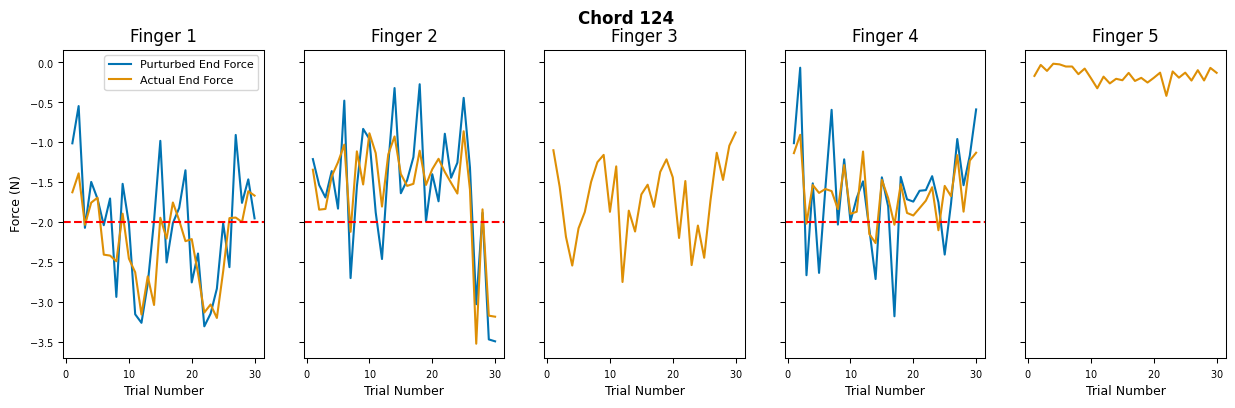

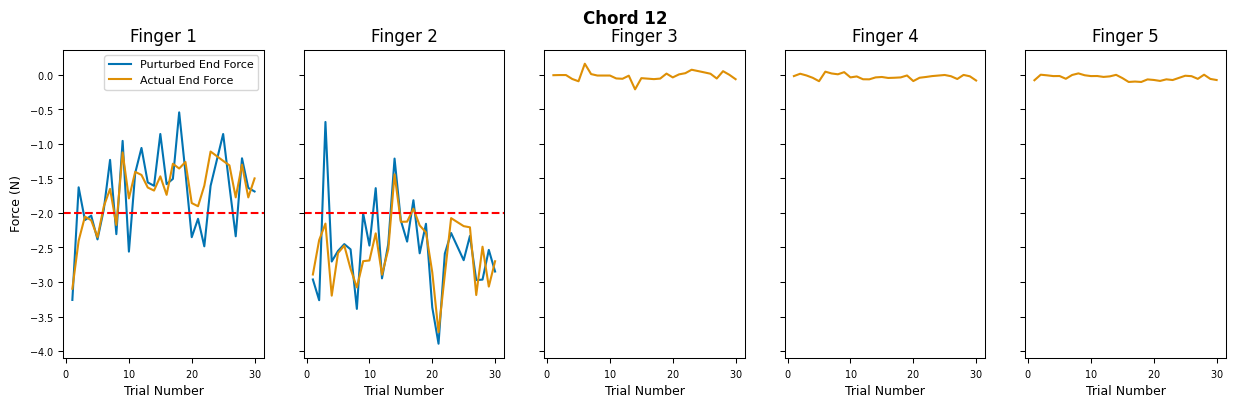

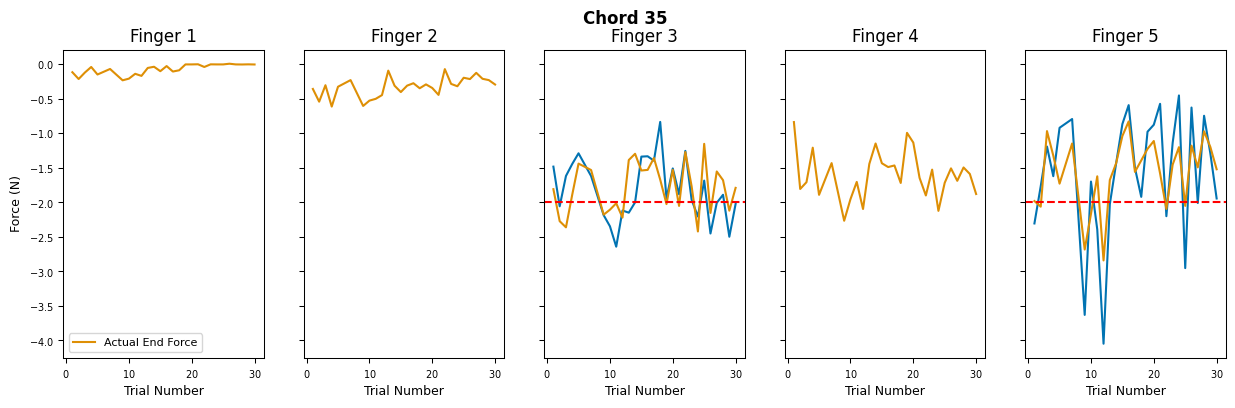

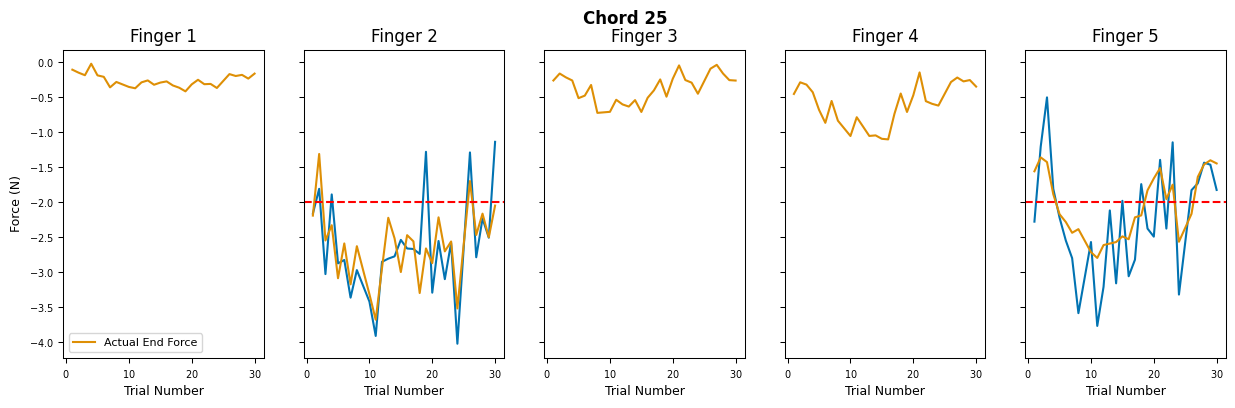

In [156]:
for bn, bn_data in subjs_correct.groupby('BN'):
    fig, axs = plt.subplots(1, 5, figsize=(15, 4), sharey=True)

    for i in range(1, 6):
        target_force = bn_data[f'targetForce{i}'].iloc[0]
        if i == 1:
            if target_force != 0:
                sns.lineplot(data = bn_data, x = 'TN', y = f'endForcePurturbed{i}', ax = axs[i-1], label = 'Purturbed End Force', color = sns.color_palette('colorblind')[0])
            sns.lineplot(data = bn_data, x = 'TN', y = f'endForce{i}', ax = axs[i-1], label = 'Actual End Force', color = sns.color_palette('colorblind')[1])
        else:
            if target_force != 0:
                sns.lineplot(data = bn_data, x = 'TN', y = f'endForcePurturbed{i}', ax = axs[i-1], label = 'Purturbed End Force', legend = False, color = sns.color_palette('colorblind')[0])
            sns.lineplot(data = bn_data, x = 'TN', y = f'endForce{i}', ax = axs[i-1], label = 'Actual End Force', legend = False, color = sns.color_palette('colorblind')[1])
        if target_force != 0:
            axs[i-1].axhline(target_force, color='red', linestyle='--')
        axs[i-1].set_title(f'Finger {i}')
        axs[i-1].set_xlabel('Trial Number')
        axs[i-1].set_ylabel('Force (N)')

    chord = extract_chord_form_target_force(bn_data.iloc[0])
    fig.suptitle(f'Chord {chord}')

Block 1 (Chord 1245):
(28, 5) (28, 5)
Mean of delta_X across trials: [0.73511111 0.78925926 0.         0.69311111 0.68766667]
[[-0.48707827  0.03343863  0.         -0.13316297  0.04326175]
 [-0.37770203  0.17252639  0.         -0.42340467 -0.61382206]
 [-0.29560379  0.20824047  0.         -0.46608071 -0.16800896]
 [ 0.19284737 -0.12985827  0.         -0.20446554 -0.06446342]
 [-0.22400751  0.09798099  0.          0.06335969 -0.59179719]]
Block 2 (Chord 123):
(27, 5) (27, 5)
Mean of delta_X across trials: [0.762      0.85765385 0.71819231 0.         0.        ]
[[-0.54164828  0.05443687 -0.23581973  0.          0.        ]
 [-0.07891585 -0.3481131   0.22046095  0.          0.        ]
 [-0.34417468 -0.40038518 -0.55466373  0.          0.        ]
 [-0.11917545 -0.13679663 -0.22669776  0.          0.        ]
 [ 0.23369491 -0.13383993 -0.12205919  0.          0.        ]]
Block 3 (Chord 245):
(28, 5) (28, 5)
Mean of delta_X across trials: [0.         0.60262963 0.         0.80251852 0.57

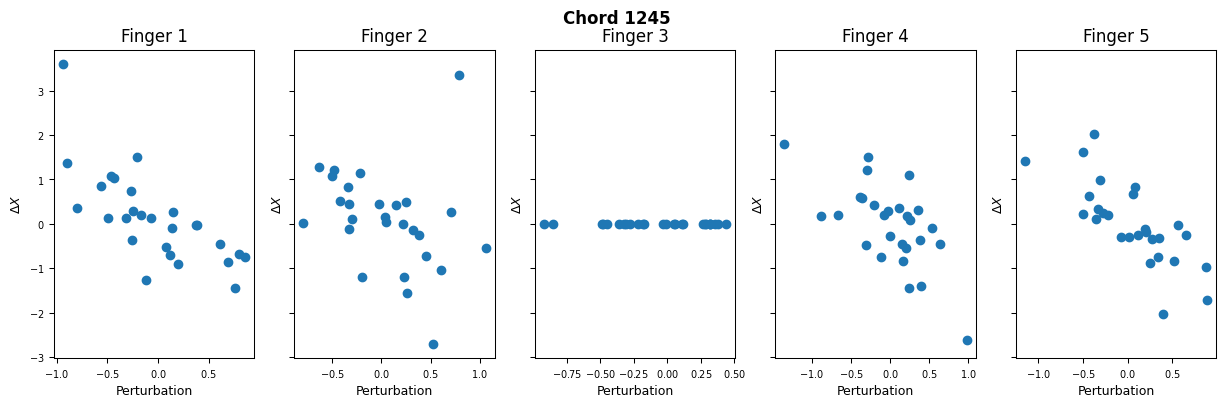

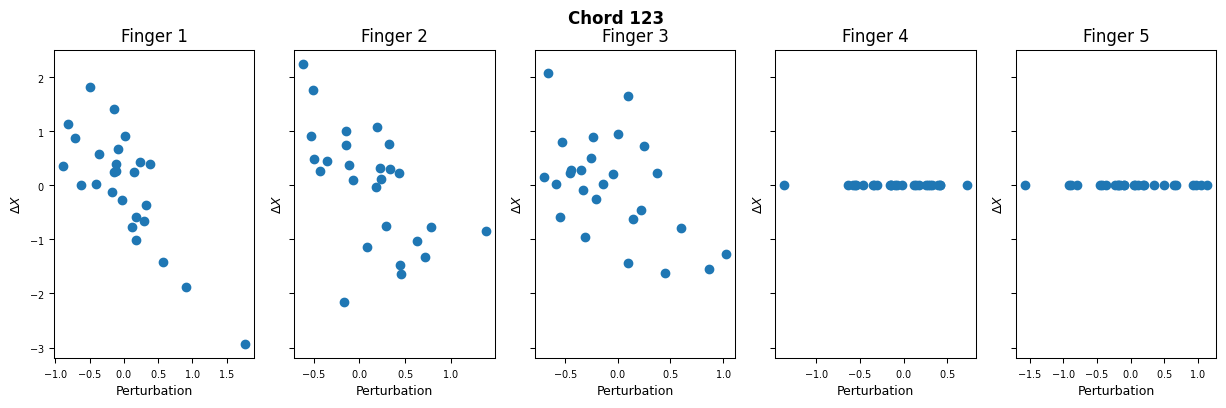

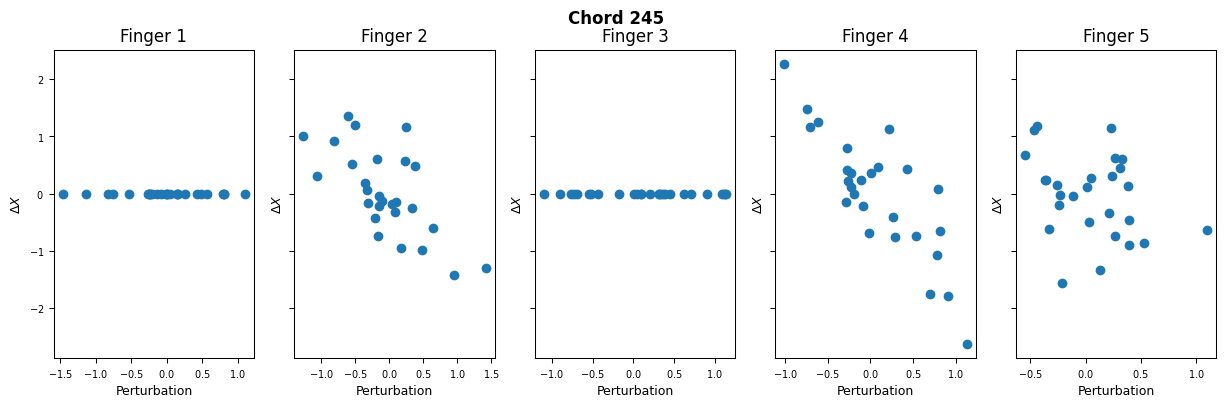

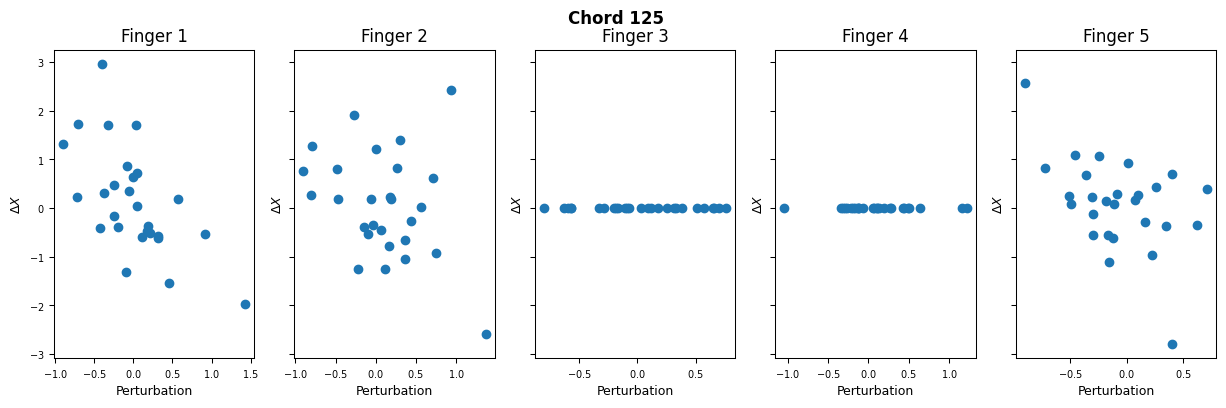

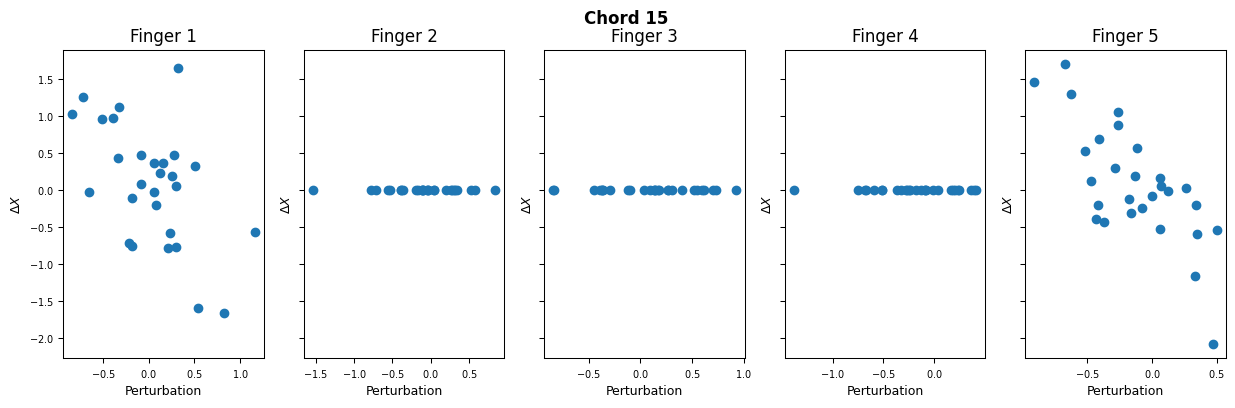

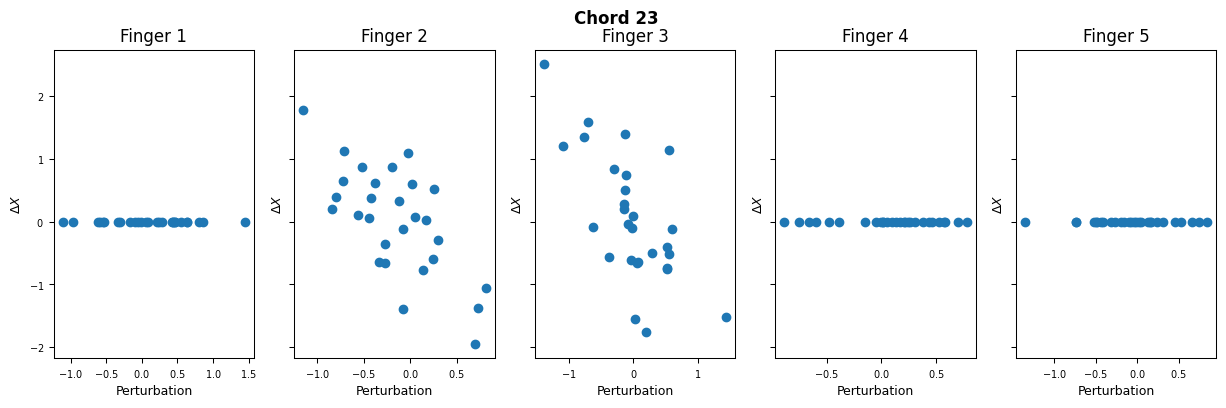

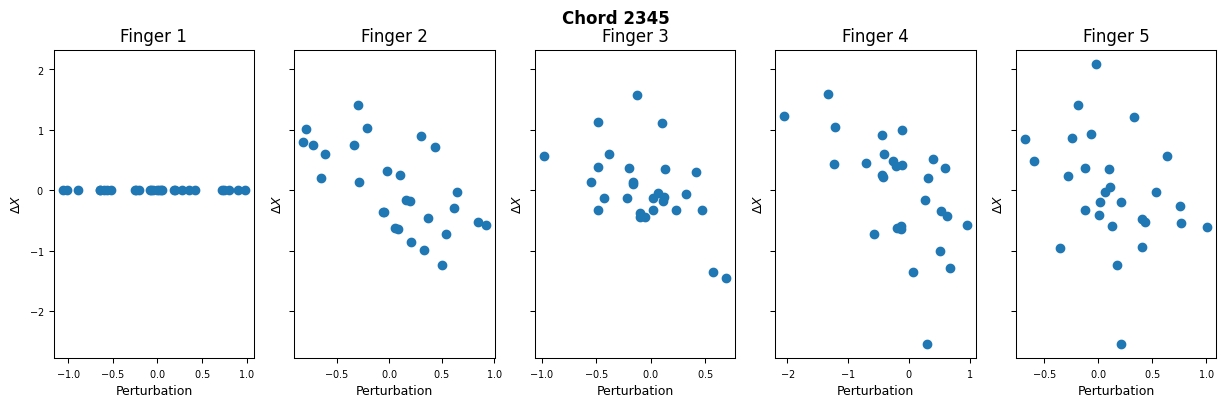

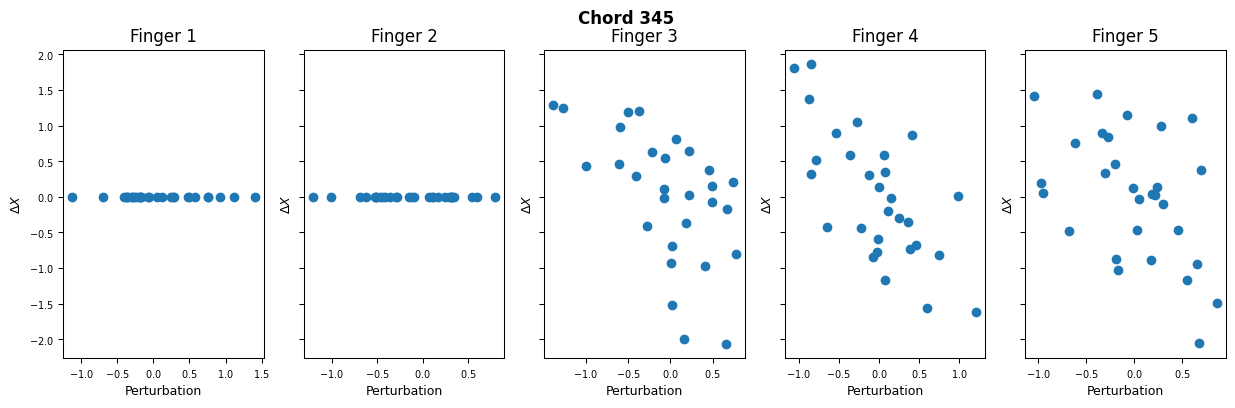

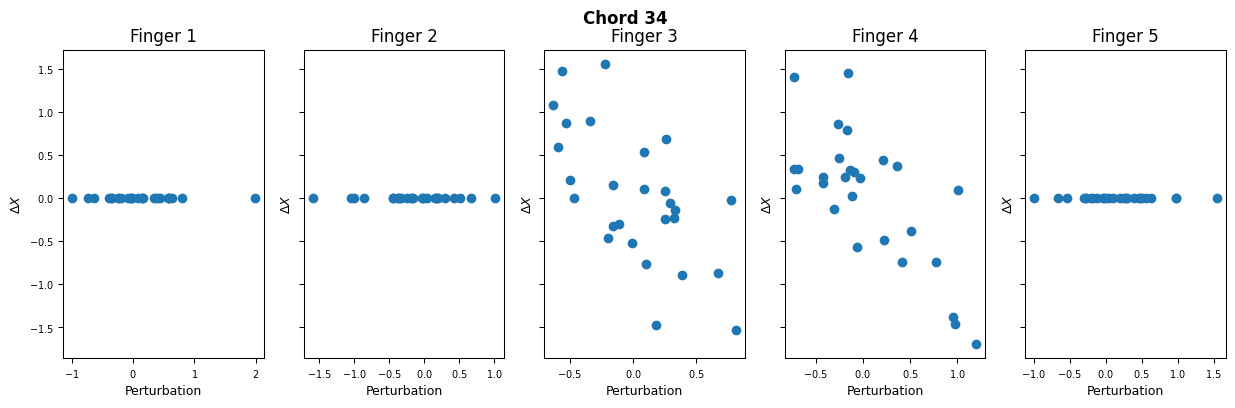

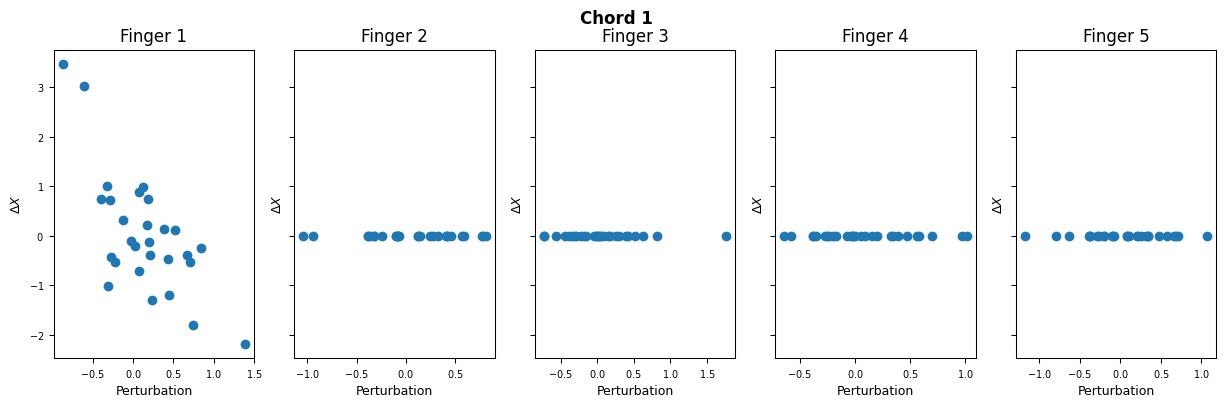

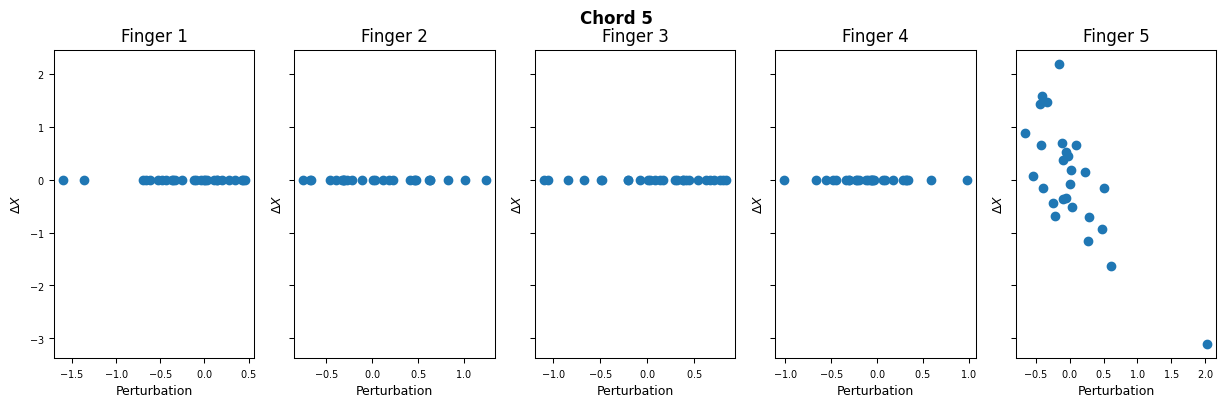

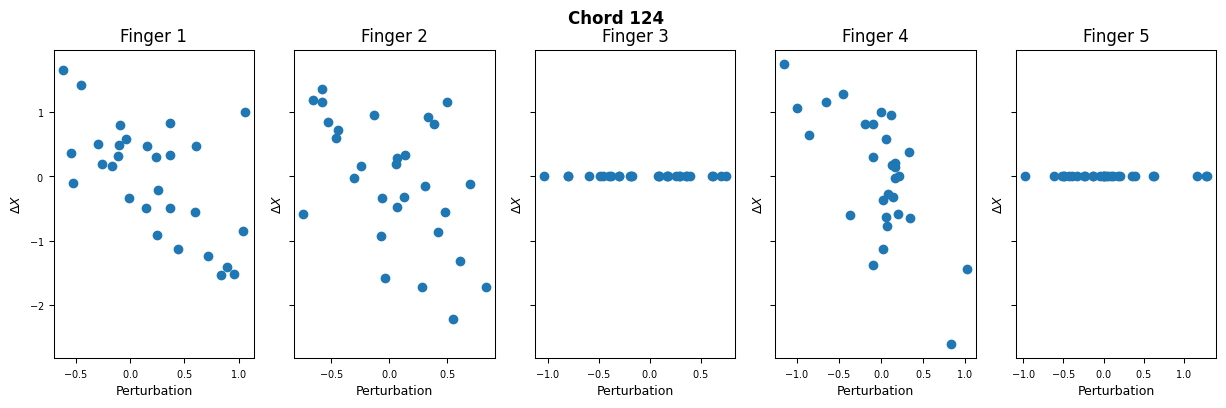

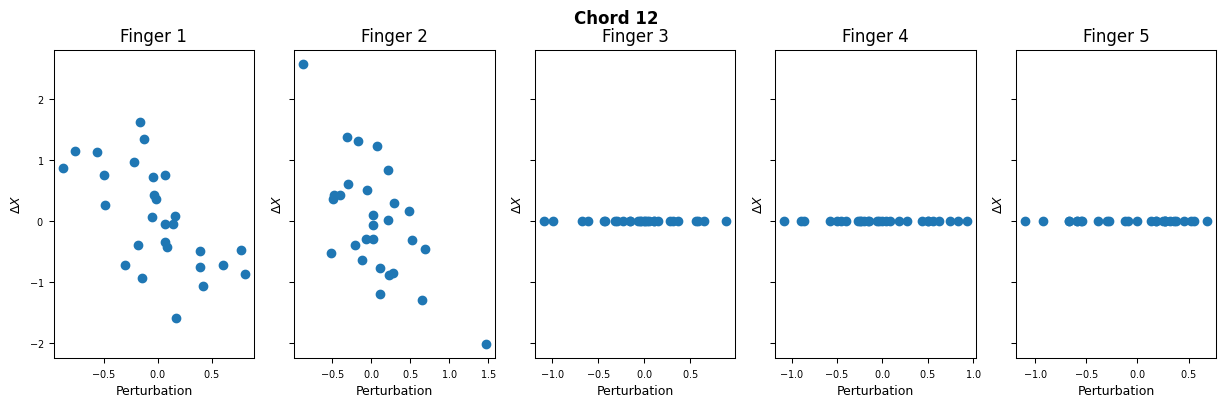

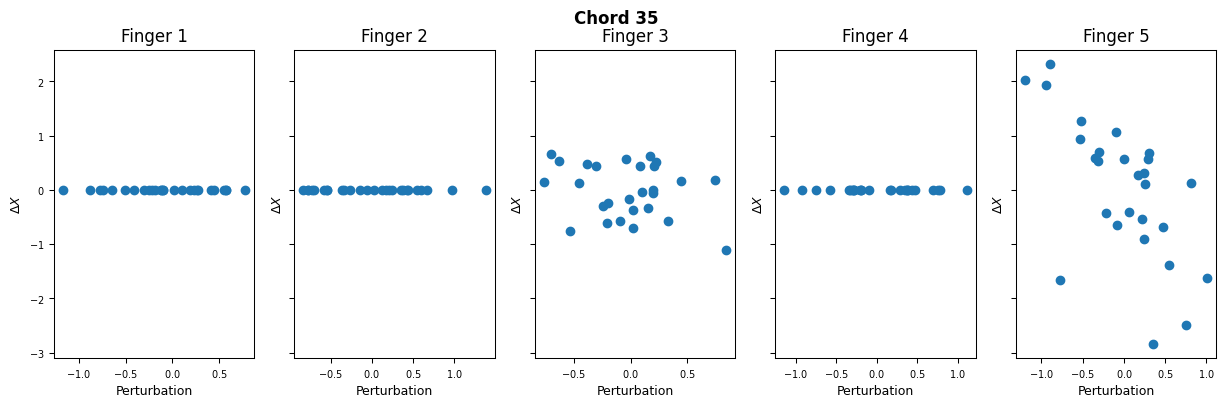

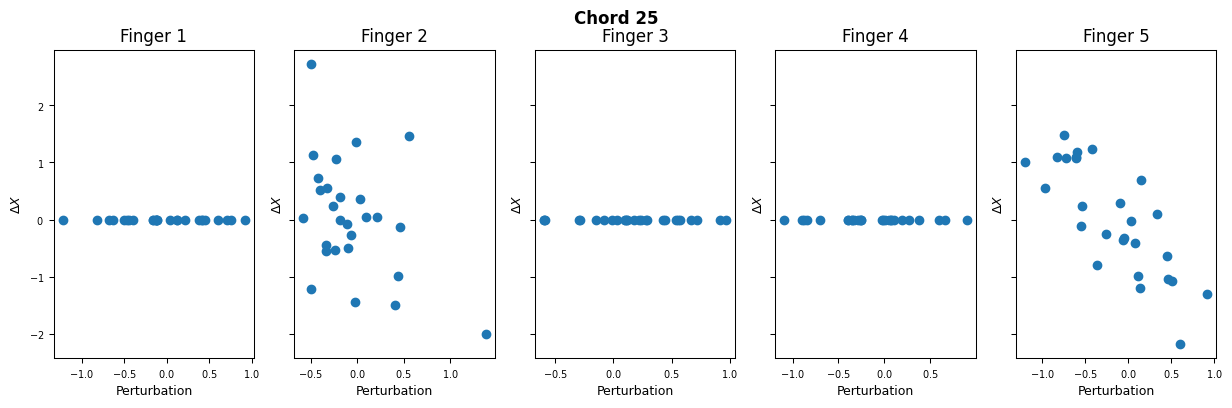

In [204]:
# assuming the following model:
# X_t = Z_t + \epsilon_t + p_t (the perturbation)
# where Z_t is the planned force, \epsilon_t is the execution noise, and p_t is the perturbation applied on trial t
# Z_t+1 = Z_t + A * (X_t - T) (the learning rule, where T is the target force and A is the learning rate)

# ==> X_t+1 = Z_t+1 + \epsilon_t+1 + p_t+1
#          = Z_t + A * (X_t - T) + \epsilon_t+1 + p_t+1
#          = Z_t + A * (Z_t + \epsilon_t + p_t - T) + \epsilon_t+1 + p_t+1

# ==> X_t+1 - X_t = A * (Z_t - T) + A * \epsilon_t + A * p_t + \epsilon_t+1 + p_t+1 - \epsilon_t - p_t
# ==> X_t+1 - X_t = A * (Z_t - T) + (A - 1) * \epsilon_t + (A - 1) * p_t + \epsilon_t+1 + p_t+1

# If we assume that the execution noise \epsilon_t is zero-mean and uncorrelated across trials, and that the perturbation p_t is also zero-mean and uncorrelated across trials,
# then we can estimate the learning rate A by regressing the trial-to-trial change in force (X_t+1 - X_t) on to p_t

# cov(X_t+1 - X_t, p_t) = cov(A * (Z_t - T) + (A - 1) * \epsilon_t + (A - 1) * p_t + \epsilon_t+1 + p_t+1, p_t)
# cov(X_t+1 - X_t, p_t) = (A - 1) * var(p_t)
# A = 1 + cov(X_t+1 - X_t, p_t) / var(p_t)

# p_t is external: N(0, std = 0.5N) independently applied on each finger, and uncorrelated across trials
# X_t is the endForcePurturbed, which is the sum of the planned force Z_t, the execution noise \epsilon_t, and the perturbation p_t

betas = []

for bn, bn_data in subjs_correct.groupby('BN'):
    chord = extract_chord_form_target_force(bn_data.iloc[0])
    print(f'Block {bn} (Chord {chord}):')
    X = bn_data[[f'endForcePurturbed{i}' for i in range(1, 6)]].values
    P = bn_data[[f'purturbation{i}' for i in range(1, 6)]].values
    print(X.shape, P.shape)
    delta_X = X[1:] - X[:-1] # shape (num_trials-1, 5)
    P_t = P[:-1] # shape (num_trials-1, 5)
    cov_X_P = np.cov(delta_X.T, P_t.T)
    cov_X_P = cov_X_P[:5, 5:] # shape (5, 5)
    var_P = np.cov(P_t.T) # shape (5, 5)
    # actual_var_P = np.eye(5) * 0.25
    # var_P = actual_var_P # shape (5, 5)
    # print(cov_X_P)
    matrix_mult = cov_X_P @ np.linalg.inv(var_P)
    # print(matrix_mult)
    A = np.eye(5) + matrix_mult
    # print(A)

    # print(np.diag(np.cov(delta_X.T)).shape)
    # delta_X_var = np.diag(np.cov(delta_X.T))
    delta_x_abs = delta_X
    for i in range(1, 6):
        if bn_data[f'targetForce{i}'].iloc[0] == 0:
            delta_x_abs[:, i-1] = 0
    mean_delta_X = np.mean(np.abs(delta_x_abs), axis=0)
    print("Mean of delta_X across trials:", mean_delta_X)


    # for fingers with targetForce = 0, make the corresponding column zero
    for i in range(1, 6):
        if bn_data[f'targetForce{i}'].iloc[0] == 0:
            A[:, i-1] = 0
    print(A)


    betas.append({
        'subNum': bn_data['subNum'].iloc[0],
        'Block': bn,
        'num_fingers': bn_data['num_targets'].iloc[0],
        'chord': chord,
        'mean_x1': mean_delta_X[0],
        'mean_x2': mean_delta_X[1],
        'mean_x3': mean_delta_X[2],
        'mean_x4': mean_delta_X[3],
        'mean_x5': mean_delta_X[4],
        'A1': np.round(A[0, 0], 2),
        'A2': np.round(A[1, 1], 2),
        'A3': np.round(A[2, 2], 2),
        'A4': np.round(A[3, 3], 2),
        'A5': np.round(A[4, 4], 2),
        'A12': np.round(A[0, 1], 2),
        'A13': np.round(A[0, 2], 2),
        'A14': np.round(A[0, 3], 2),
        'A15': np.round(A[0, 4], 2),
        'A21': np.round(A[1, 0], 2),
        'A23': np.round(A[1, 2], 2),
        'A24': np.round(A[1, 3], 2),
        'A25': np.round(A[1, 4], 2),
        'A31': np.round(A[2, 0], 2),
        'A32': np.round(A[2, 1], 2),
        'A34': np.round(A[2, 3], 2),
        'A35': np.round(A[2, 4], 2),
        'A41': np.round(A[3, 0], 2),
        'A42': np.round(A[3, 1], 2),
        'A43': np.round(A[3, 2], 2),
        'A45': np.round(A[3, 4], 2),
        'A51': np.round(A[4, 0], 2),
        'A52': np.round(A[4, 1], 2),
        'A53': np.round(A[4, 2], 2),
        'A54': np.round(A[4, 3], 2),
    })


    fig, axs = plt.subplots(1, 5, figsize=(15, 4), sharey=True)

    for i in range(1, 6):
        axs[i-1].scatter(P_t[:, i-1], delta_X[:, i-1])
        target_force = bn_data[f'targetForce{i}'].iloc[0]
        axs[i-1].set_title(f'Finger {i}')
        axs[i-1].set_xlabel('Perturbation')
        axs[i-1].set_ylabel(r'$\Delta X$')

    chord = extract_chord_form_target_force(bn_data.iloc[0])
    fig.suptitle(f'Chord {chord}')

betas = pd.DataFrame(betas)

In [162]:
betas

,subNum,Block,num_fingers,chord,A1,A2,A3,A4,A5,A12,...,A34,A35,A41,A42,A43,A45,A51,A52,A53,A54
0,1,1,4,1245,-0.49,0.17,0.00,-0.20,-0.59,0.03,...,-0.47,-0.17,0.19,-0.13,0.00,-0.06,-0.22,0.10,0.00,0.06
1,1,2,3,123,-0.54,-0.35,-0.55,0.00,0.00,0.05,...,0.00,0.00,-0.12,-0.14,-0.23,0.00,0.23,-0.13,-0.12,0.00
2,1,3,3,245,0.00,0.07,0.00,-0.54,0.84,0.27,...,-0.35,0.05,0.00,-0.00,0.00,-0.04,0.00,0.40,0.00,0.47
3,1,4,3,125,-0.04,0.53,0.00,0.00,-0.11,0.52,...,0.00,-0.12,-0.14,-0.13,0.00,0.56,-0.26,0.29,0.00,0.00
4,1,5,2,15,0.00,0.00,0.00,0.00,-0.70,0.00,...,0.00,0.25,0.32,0.00,0.00,0.07,0.40,0.00,0.00,0.00
5,1,6,2,23,0.00,-0.03,-0.16,0.00,0.00,-0.01,...,0.00,0.00,0.00,0.16,0.25,0.00,0.00,0.30,0.14,0.00
6,1,7,4,2345,0.00,0.15,0.17,0.17,0.27,0.17,...,-0.09,0.06,0.00,0.14,0.36,0.05,0.00,0.31,-0.56,-0.04
7,1,8,3,345,0.00,0.00,0.12,-0.12,0.20,0.00,...,-0.00,0.34,0.00,0.00,0.20,-0.25,0.00,0.00,-0.09,-0.26
8,1,9,2,34,0.00,0.00,-0.29,-0.03,0.00,0.00,...,-0.17,0.00,0.00,0.00,-0.02,0.00,0.00,0.00,-0.10,0.08
9,1,10,1,1,-0.78,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,-0.14,0.00,0.00,0.00,0.26,0.00,0.00,0.00


In [163]:
# mean non zero A across fingers for each block
betas['mean_A'] = betas[['A1', 'A2', 'A3', 'A4', 'A5']].replace(0, np.nan).mean(axis=1)
    

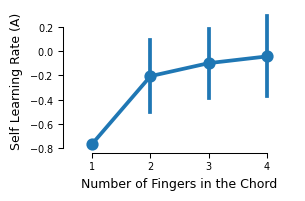

In [164]:
sns.pointplot(data = betas, x = 'num_fingers', y = 'mean_A', errorbar='sd')
plt.xlabel('Number of Fingers in the Chord')
plt.ylabel('Self Learning Rate (A)')
sns.despine(trim = True)

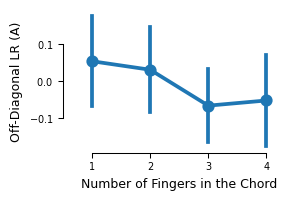

In [186]:
# mean of the off-diagonal elements of A across fingers for each block
off_diag_cols = [col for col in betas.columns if len(col) == 3]
betas ['mean_off_diag_A'] = betas[off_diag_cols].replace(0, np.nan).mean(axis=1)

sns.pointplot(data = betas, x = 'num_fingers', y = 'mean_off_diag_A', errorbar='sd')
plt.xlabel('Number of Fingers in the Chord')
plt.ylabel('Off-Diagonal LR (A)')
sns.despine(trim = True)

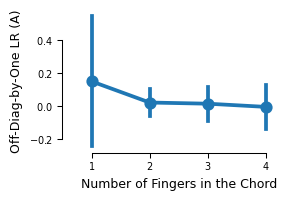

In [185]:
# mean of the diagonals off the main diagonal by one (i.e., A12, A21, A23, A32, A34, A43, A45, A54)
off_diag_1_cols = ['A12', 'A21', 'A23', 'A32', 'A34', 'A43', 'A45', 'A54']

betas ['mean_off_diag_1_A'] = betas[off_diag_1_cols].replace(0, np.nan).mean(axis=1)
sns.pointplot(data = betas, x = 'num_fingers', y = 'mean_off_diag_1_A', errorbar='sd')
plt.xlabel('Number of Fingers in the Chord')
plt.ylabel('Off-Diag-by-One LR (A)')
sns.despine(trim = True)

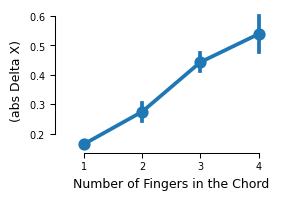

In [206]:
# mean of delta x  on fingers
betas['mean_delta_x'] = betas[[f'mean_x{i}' for i in range(1, 6)]].mean(axis=1)
sns.pointplot(data = betas, x = 'num_fingers', y = 'mean_delta_x', errorbar='sd')
plt.xlabel('Number of Fingers in the Chord')
plt.ylabel('(abs Delta X)')
sns.despine(trim = True)

In [131]:
# assuming the following model:
# X_t = Z_t + \epsilon_t + p_t (the perturbation)
# where Z_t is the planned force, \epsilon_t is the execution noise, and p_t is the perturbation applied on trial t
# Z_t+1 = Z_t + A * (X_t - T) (the learning rule, where T is the target force and A is the learning rate)

# ==> X_t+1 = Z_t+1 + \epsilon_t+1 + p_t+1
#          = Z_t + A * (X_t - T) + \epsilon_t+1 + p_t+1
#          = Z_t + A * (Z_t + \epsilon_t + p_t - T) + \epsilon_t+1 + p_t+1

# ==> X_t+1 - X_t = A * (Z_t - T) + A * \epsilon_t + A * p_t + \epsilon_t+1 + p_t+1 - \epsilon_t - p_t
# ==> X_t+1 - X_t = A * (Z_t - T) + (A - 1) * \epsilon_t + (A - 1) * p_t + \epsilon_t+1 + p_t+1

# If we assume that the execution noise \epsilon_t is zero-mean and uncorrelated across trials, and that the perturbation p_t is also zero-mean and uncorrelated across trials,
# then we can estimate the learning rate A by regressing the trial-to-trial change in force (X_t+1 - X_t) on to p_t

# cov(X_t+1 - X_t, p_t) = cov(A * (Z_t - T) + (A - 1) * \epsilon_t + (A - 1) * p_t + \epsilon_t+1 + p_t+1, p_t)
# cov(X_t+1 - X_t, p_t) = (A - 1) * var(p_t)
# A = 1 + cov(X_t+1 - X_t, p_t) / var(p_t)

# p_t is external: N(0, std = 0.5N) independently applied on each finger, and uncorrelated across trials
# X_t is the endForcePurturbed, which is the sum of the planned force Z_t, the execution noise \epsilon_t, and the perturbation p_t

betas = []

for bn, bn_data in subjs_correct.groupby('BN'):
    chord = extract_chord_form_target_force(bn_data.iloc[0])
    print(f'Block {bn} (Chord {chord}):')
    X = bn_data[[f'endForcePurturbed{i}' for i in range(1, 6)]].values
    P = bn_data[[f'purturbation{i}' for i in range(1, 6)]].values
    print(X.shape, P.shape)
    delta_X = X[1:] - X[:-1] # shape (num_trials-1, 5)
    P_t = P[:-1] # shape (num_trials-1, 5)

    shown_indices = []
    for i in range(1, 6):
        if bn_data[f'targetForce{i}'].iloc[0] != 0:
            shown_indices.append(i-1)

    P_t_active = P_t[:, shown_indices]
    # P_t_active = P_t

    A = np.full((5, 5), np.nan)

    for i in range(5):
        y = delta_X[:, i]
        model = sm.OLS(y, P_t_active).fit()
        A[i, shown_indices] = model.params
        # A[i,:] = model.params
    
    for i in shown_indices:
        A[i,i] += 1
    print(A)

    betas.append({
        'subNum': bn_data['subNum'].iloc[0],
        'Block': bn,
        'num_fingers': bn_data['num_targets'].iloc[0],
        'chord': chord,
        'A1': np.round(A[0, 0], 2),
        'A2': np.round(A[1, 1], 2),
        'A3': np.round(A[2, 2], 2),
        'A4': np.round(A[3, 3], 2),
        'A5': np.round(A[4, 4], 2)
    })



betas = pd.DataFrame(betas)

Block 1 (Chord 1245):
(28, 5) (28, 5)
[[-0.48036156  0.10035207         nan -0.11442583  0.09995872]
 [-0.35873042  0.33427456         nan -0.37563648 -0.47654412]
 [-0.34844187 -0.0129781          nan -0.55574599 -0.35797989]
 [ 0.18515666 -0.16786222         nan -0.21861478 -0.09698478]
 [-0.21015178  0.1884765          nan  0.09301841 -0.51472482]]
Block 2 (Chord 123):
(27, 5) (27, 5)
[[-0.55324888 -0.04387062 -0.19052891         nan         nan]
 [ 0.02442651 -0.22105833  0.13559647         nan         nan]
 [-0.46713658 -0.55513455 -0.47140254         nan         nan]
 [-0.10552821 -0.29303505 -0.16526565         nan         nan]
 [ 0.57699579  0.00094619 -0.20408364         nan         nan]]
Block 3 (Chord 245):
(28, 5) (28, 5)
[[        nan  0.15228444         nan  0.20847543  0.18464851]
 [        nan  0.13641317         nan -0.31500404 -0.47678475]
 [        nan -0.21493104         nan -0.46306143  0.42781279]
 [        nan  0.03720544         nan -0.6079502  -0.08993906]
 [  

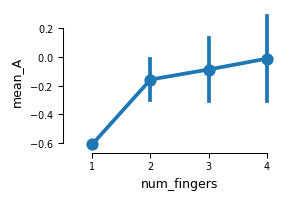

In [135]:
# mean non zero A across fingers for each block
betas['mean_A'] = betas[['A1', 'A2', 'A3', 'A4', 'A5']].replace(0, np.nan).mean(axis=1)
    
sns.pointplot(data = betas, x = 'num_fingers', y = 'mean_A', errorbar='sd')
sns.despine(trim = True)